# 🤖 Clasificación Binaria de Etiquetas MPLS
Este cuaderno tiene como objetivo entrenar y comparar modelos supervisados para clasificar etiquetas de red como **correctas (clase = 1)** o **incorrectas (clase = 0)**.

El dataset utilizado ha sido validado previamente y contiene ejemplos tanto reales como simulados.

📅 Generado automáticamente el: 2025-09-29 20:33:19

## 📚 Importar librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")


## 📥 Cargar el dataset validado

In [3]:
# Cargar el archivo final validado
df = pd.read_csv("dataset_etiquetas_cajas_mpls_vfinal.csv")
df.head()


,N,Etiqueta,TS,ciudad,nodo_concentrador,nodo_estandar,nodo_backup,ruta,caja_codigo,color_buffer,tipo_ruta,clase,detalle_validacion
0,1.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE16B,CAF,ruta_completa,1,Etiqueta valida
1,2.0,UIO-Gosseal (A)-Whymper (E)(A)/Whymper (E)(B)-...,UIO,UIO,Gosseal (A),Whymper (E)(A),Whymper (E)(B),F02,PE15B,CAF,ruta_completa,1,Etiqueta valida
2,3.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE14B,CAF,ruta_completa,1,Etiqueta valida
3,4.0,UIO-Gosseal (A)-Whymper (E)(A)/Whymper (E)(B)-...,UIO,UIO,Gosseal (A),Whymper (E)(A),Whymper (E)(B),F02,PE13B,CAF,ruta_completa,1,Etiqueta valida
4,5.0,UIO-Gosseal (A)-Whymper (E)(B)/Whymper (E)(A)-...,UIO,UIO,Gosseal (A),Whymper (E)(B),Whymper (E)(A),F02,PE12B,VER,ruta_completa,1,Etiqueta valida


## 🧹 Preprocesamiento de variables

In [5]:
# Seleccionar variables categóricas como input
features = ['ciudad', 'nodo_concentrador', 'nodo_estandar', 'ruta', 'caja_codigo', 'color_buffer', 'tipo_ruta']
X = df[features]
y = df['clase']

# Codificación one-hot para variables categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)


## 🌲 Entrenamiento con Random Forest

In [6]:
# Crear y entrenar el modelo
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predecir en datos de prueba
y_pred_rf = rf.predict(X_test)


### 📈 Métricas de desempeño – Random Forest

🔍 Resultados - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00       124

    accuracy                           1.00       164
   macro avg       1.00      1.00      1.00       164
weighted avg       1.00      1.00      1.00       164



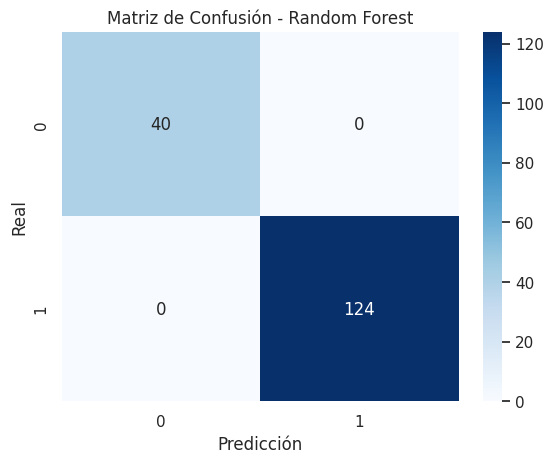

In [7]:
print("🔍 Resultados - Random Forest")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


## 💡 Entrenamiento con Support Vector Machine (SVM)

In [8]:
# Crear y entrenar modelo SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Predicción
y_pred_svm = svm.predict(X_test)


### 📈 Métricas de desempeño – SVM

🔍 Resultados - SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00       124

    accuracy                           1.00       164
   macro avg       1.00      1.00      1.00       164
weighted avg       1.00      1.00      1.00       164



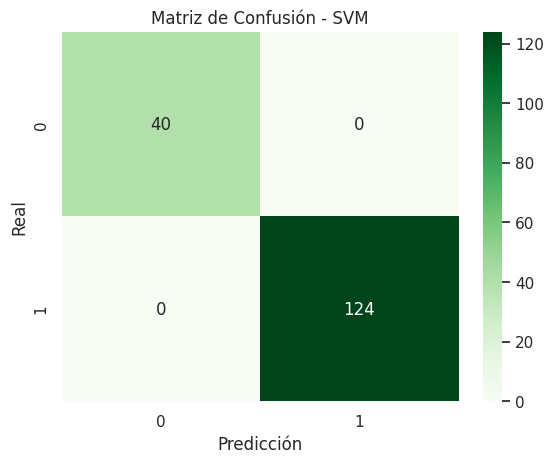

In [9]:
print("🔍 Resultados - SVM")
print(classification_report(y_test, y_pred_svm))

# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


## ✅ Conclusiones
Este cuaderno establece un baseline para modelos supervisados usando Random Forest y SVM. Los resultados obtenidos sirven como punto de comparación para modelos más complejos como redes neuronales o transformers.